In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:15pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:15pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# ※ ①naver open API를 활용하여 네이버지식인 "전주여행"과 "경주여행"을 각각 500건씩 검색(re ? )후 백업 -> ②품사태깅 백업 -> ③명사만 추출 -> ④빈도분석(DataFrame) 후 백업-> ⑤빈도 시각화(워드클라우드, Text) ->⑥ Word2Vec

# 1. 네이버 open API를 활용하여 검색 추출
- 검색어, no, title, link, description, title + ' ' + description(total_text)

In [1]:
import requests
from bs4 import BeautifulSoup
from konlpy.tag import Kkma
import time
import json # response 텍스트를 json 딕셔너리로
from html import unescape # description에 있는 &lt;(특수문자)을 <으로 변경, &gt;-> >
import pandas as pd
import re

In [2]:
#pip install python-dotenv (환경변수를 쓰기 위한 라이브러리)
#pip install python-decouple (주피터 환경에서는 안 될 수도 있음)
import  os
os.getcwd() #현재 작업디렉토리

'C:\\ai_x\\source\\07_자연어처리'

In [4]:
%ls .env

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: 3664-591E

 C:\ai_x\source\07_자연어처리 디렉터리

2025-06-18  오후 05:48                56 .env
               1개 파일                  56 바이트
               0개 디렉터리  118,627,807,232 바이트 남음


In [5]:
from dotenv import load_dotenv
load_dotenv()
print(os.getenv('Client_ID'))
print(os.getenv('Client_Secret'))

AYfT_6KERF5DIoARIprd
F20oajAL_D


In [6]:
from decouple import config
print(config('Client_ID'))
print(config('Client_Secret'))

AYfT_6KERF5DIoARIprd
F20oajAL_D


In [21]:
def save_file(query, start):
    client_id = os.getenv('Client_ID')
    client_secret = os.getenv('Client_Secret')
    headers = {'X-Naver-Client-Id':client_id,
              'X-Naver-Client-Secret':client_secret}
    url = "https://openapi.naver.com/v1/search/kin.json?query={}&display=100&start={}".format(query, start+1)
    response = requests.get(url, headers = headers)
    items = json.loads(response.text)['items']
    result = []
    for i, item in enumerate(items):
        title = item['title'].replace('<b>', ' ').replace('</b>', ' ')
        link = item['link']
        description = item['description'].replace('<b>', ' ').replace('</b>', ' ')
    #       print('수정전 :', description)
        description = unescape(description) # html 특수문자 처리(&lt; -> <로 대체)
        description = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', description)
        description = re.sub('\s+', ' ', description)
    #         print('수정후 :', description)
            # print(query, (start*100+i+1), title, link, description, title+' ' +description)
        result.append({'query':query,
                      'no':start*100+i+1,
                      'title':title,
                      'link':link,
                      'description':description,
                      'total_text':title+ ' ' + description})
    return result

In [27]:
queries = ['전주 여행', '경주 여행']
all_results = []
for query in queries:
    max_start = 5
    for start in range(max_start):
        print(start, query, '읽는 중')
        save_file(query, start)
        all_results.extend(save_file(query, start))
        time.sleep(0.5)

0 전주 여행 읽는 중
1 전주 여행 읽는 중
2 전주 여행 읽는 중
3 전주 여행 읽는 중
4 전주 여행 읽는 중
0 경주 여행 읽는 중
1 경주 여행 읽는 중
2 경주 여행 읽는 중
3 경주 여행 읽는 중
4 경주 여행 읽는 중


In [29]:
df = pd.DataFrame(all_results)
df.to_csv('data/naver_kin.csv', index=False, sep='\t')

# 2. 품사태깅 백업

In [50]:
df1 = pd.read_csv('data/naver_kin.csv', sep='\t')
df1

,query,no,title,link,description,total_text
0,전주 여행,1,전주 가볼만한곳 추천 받아요,https://kin.naver.com/qna/detail.naver?d1id=9&...,추억의 7080 다양한체험 7080감성 추억여행 테마박물관 유익한시간 2 전북 전...,전주 가볼만한곳 추천 받아요 추억의 7080 다양한체험 7080감성 추억여행 ...
1,전주 여행,2,전주여행 갈려고하는데요!,https://kin.naver.com/qna/detail.naver?d1id=9&...,전주여행 을 갈려고하는데요 아는사람과 갈려고하는데 호텔은 좋은가격에 정했고 음 2...,전주여행 갈려고하는데요! 전주여행 을 갈려고하는데요 아는사람과 갈려고하는데 호텔...
2,전주 여행,3,전주 1박 2일 여행 관련 질문~,https://kin.naver.com/qna/detail.naver?d1id=9&...,전주 여행 을 계획하고 계시다니 정말 좋은 선택을 하셨네요 전주는 한옥마을과 함께...,전주 1박 2일 여행 관련 질문~ 전주 여행 을 계획하고 계시다니 정말 좋...
3,전주 여행,4,중2 여학생 친구와 전주여행,https://kin.naver.com/qna/detail.naver?d1id=9&...,안녕하세요 중 2 15살 여학생입니다 친한친구와 둘이서 전주 여행 을 가기로 했는데...,중2 여학생 친구와 전주여행 안녕하세요 중 2 15살 여학생입니다 친한친구와 둘...
4,전주 여행,5,부모닝 모시고 전주여행,https://kin.naver.com/qna/detail.naver?d1id=9&...,부모님 모시고 전주여행 가려는데 명소 식당 추천부탁드립니다 전주는 한옥마을로 유명한...,부모닝 모시고 전주여행 부모님 모시고 전주여행 가려는데 명소 식당 추천부탁드립니...
...,...,...,...,...,...,...
995,경주 여행,496,경주 여행 가려구요,https://kin.naver.com/qna/detail.naver?d1id=9&...,경주 여행 가려고 하는데 11월 초에나 갈 것 같아요 그쯤 되면 날씨가 많이 추울...,경주 여행 가려구요 경주 여행 가려고 하는데 11월 초에나 갈 것 같아요 그쯤 ...
996,경주 여행,497,"경주 여행 코스, 신경주역 경주역 질문 드려요",https://kin.naver.com/qna/detail.naver?d1id=9&...,안녕하세요 20대 여성이고요 친구랑 여행 가려고 계획짜고 있는데 경주 여행 은 처음...,"경주 여행 코스, 신경주역 경주역 질문 드려요 안녕하세요 20대 여성이고요 친구랑..."
997,경주 여행,498,7월 말에 경주 여행 을 계획했는데..비피해 어떤가요??,https://kin.naver.com/qna/detail.naver?d1id=9&...,7월말에 경주 여행 을 계획했는데 뉴스보니 비가 계속 많이 오더라구요 여행을 미뤄...,7월 말에 경주 여행 을 계획했는데..비피해 어떤가요?? 7월말에 경주 여행 을...
998,경주 여행,499,2박 경주여행,https://kin.naver.com/qna/detail.naver?d1id=9&...,11월 중순에 남편과 경주여행 을 계획하고 있는데요 처음 가보는곳이라 첫날은 황남관...,2박 경주여행 11월 중순에 남편과 경주여행 을 계획하고 있는데요 처음 가보는곳...


In [51]:
df_list = df1[['query', 'no', 'total_text']].values.tolist()
stopwords = ['전주', '경주', '여행']
select_pos = ['NNG', 'NNP']
postagged_lst = []
for i, row in enumerate(df_list):
    query = row[0]
    no = row[1]
    total_text = row[2]
    text_pos = mecab.pos(total_text)
    for token, pos in text_pos:
        if token not in stopwords:
            postagged_lst.append({'query':query,
                                  'no':no,
                                  'token':token,
                                  'pos':pos})
df_postagged = pd.DataFrame(postagged_lst)
df_postagged

,query,no,token,pos
0,전주 여행,1,가,VV
1,전주 여행,1,볼,EC+VX+ETM
2,전주 여행,1,만,NNB
3,전주 여행,1,한,XSA+ETM
4,전주 여행,1,곳,NNG
...,...,...,...,...
54127,경주 여행,500,를,JKO
54128,경주 여행,500,방문,NNG
54129,경주 여행,500,하,XSV
54130,경주 여행,500,시,EP


In [54]:
df_postagged.to_csv('data/naver_kin_pos.csv', index=False, sep='\t')

# 3. 명사만 추출

In [55]:
df_postagged = pd.read_csv('data/naver_kin_pos.csv', sep='\t')

In [56]:
select_pos = ['NNG', 'NNP']

In [59]:
df_nouns = df_postagged.loc[df_postagged['pos'].isin(select_pos),
                           ['query', 'token', 'pos']]
df_nouns

,query,token,pos
4,전주 여행,곳,NNG
5,전주 여행,추천,NNG
8,전주 여행,추억,NNG
11,전주 여행,다양,NNG
13,전주 여행,체험,NNG
...,...,...,...
54122,경주 여행,참고,NNG
54124,경주 여행,쭈니,NNP
54125,경주 여행,아빠,NNG
54126,경주 여행,블로그,NNG


In [60]:
df_nouns.to_csv('data/naver_kin_pos_nouns.csv', index=False, sep='\t')

# 4. 빈도분석(DataFrame) 후 백업

In [61]:
df_nouns = pd.read_csv('data/naver_kin_pos_nouns.csv', sep='\t')
df_nouns.iloc[::5000]

,query,token,pos
0,전주 여행,곳,NNG
5000,전주 여행,제주도,NNP
10000,경주 여행,길,NNG
15000,경주 여행,반려,NNG


In [62]:
df_nouns.groupby(['query', 'token'], as_index=False)['pos'].count()

,query,token,pos
0,경주 여행,가격,10
1,경주 여행,가능,24
2,경주 여행,가본적,5
3,경주 여행,가성,5
4,경주 여행,가시,5
...,...,...,...
1001,전주 여행,회관,5
1002,전주 여행,후,5
1003,전주 여행,휴가,5
1004,전주 여행,휴무,5


In [63]:
df_token_group = df_nouns.groupby('query')['token'].value_counts()
df_token_group

query  token
경주 여행  코스       446
       추천       401
       계획       154
       곳        146
       숙소       139
               ... 
전주 여행  통합         1
       패스         1
       편안         1
       필수         1
       핫          1
Name: token, Length: 1006, dtype: int64

In [64]:
df_token_group = df_token_group.reset_index(name='token_count')
df_token_group

,query,token,token_count
0,경주 여행,코스,446
1,경주 여행,추천,401
2,경주 여행,계획,154
3,경주 여행,곳,146
4,경주 여행,숙소,139
...,...,...,...
1001,전주 여행,통합,1
1002,전주 여행,패스,1
1003,전주 여행,편안,1
1004,전주 여행,필수,1


In [66]:
#전주 여행과 경주 여행 빈도 추출
import numpy as np
df_kj = df_token_group.loc[df_token_group['query']=='경주 여행', ['token', 'token_count']]
df_jj = df_token_group.loc[df_token_group['query']=='전주 여행', ['token', 'token_count']]

In [70]:
df_kj.head()

,token,token_count
0,코스,446
1,추천,401
2,계획,154
3,곳,146
4,숙소,139


In [71]:
df_jj.head()

,token,token_count
523,코스,481
524,곳,455
525,봉,354
526,여수,349
527,전,314


In [75]:
df_mrg = pd.merge(df_kj, df_jj, how='outer', on='token')
df_mrg

,token,token_count_x,token_count_y
0,코스,446.0,481.0
1,추천,401.0,301.0
2,계획,154.0,61.0
3,곳,146.0,455.0
4,숙소,139.0,60.0
...,...,...,...
798,유익,NaN,1.0
799,찜질방,NaN,1.0
800,카페이,NaN,1.0
801,통합,NaN,1.0


In [77]:
df_mrg.columns =['token', '경주', '전주']
df_mrg.fillna(0, inplace=True)
df_mrg['경주'] = df_mrg['경주'].astype(int)
df_mrg['전주'] = df_mrg['전주'].astype(int)
df_mrg

,token,경주,전주
0,코스,446,481
1,추천,401,301
2,계획,154,61
3,곳,146,455
4,숙소,139,60
...,...,...,...
798,유익,0,1
799,찜질방,0,1
800,카페이,0,1
801,통합,0,1


In [81]:
df_mrg['전체'] = df_mrg['경주'] + df_mrg['전주']
df_mrg['경주비율'] = df_mrg['경주']/df_mrg['전체']
df_mrg['전주비율'] = df_mrg['전주']/df_mrg['전체']
df_mrg.head()

,token,경주,전주,전체,경주비율,전주비율
0,코스,446,481,927,0.481122,0.518878
1,추천,401,301,702,0.571225,0.428775
2,계획,154,61,215,0.716279,0.283721
3,곳,146,455,601,0.242928,0.757072
4,숙소,139,60,199,0.698492,0.301508


In [92]:
df_mrg_srt = df_mrg.sort_values(by=['전체'], ascending=False)
df_mrg_srt.head()

,token,경주,전주,전체,경주비율,전주비율
0,코스,446,481,927,0.481122,0.518878
1,추천,401,301,702,0.571225,0.428775
3,곳,146,455,601,0.242928,0.757072
5,맛집,120,287,407,0.294840,0.705160
523,봉,0,354,354,0.000000,1.000000


In [93]:
df_mrg_srt['경주비율'] = df_mrg_srt['경주비율'].apply(lambda x : "{:.2%}".format(x))
df_mrg_srt['전주비율'] = df_mrg_srt['전주비율'].apply(lambda x : "{:.2%}".format(x))
df_mrg_srt.head()

,token,경주,전주,전체,경주비율,전주비율
0,코스,446,481,927,48.11%,51.89%
1,추천,401,301,702,57.12%,42.88%
3,곳,146,455,601,24.29%,75.71%
5,맛집,120,287,407,29.48%,70.52%
523,봉,0,354,354,0.00%,100.00%


In [100]:
df_mrg_srt.reset_index(drop=True, inplace=True)
df_mrg_srt

,token,경주,전주,전체,경주비율,전주비율
0,코스,446,481,927,48.11%,51.89%
1,추천,401,301,702,57.12%,42.88%
2,곳,146,455,601,24.29%,75.71%
3,맛집,120,287,407,29.48%,70.52%
4,봉,0,354,354,0.00%,100.00%
...,...,...,...,...,...,...
798,전용,1,0,1,100.00%,0.00%
799,권역,1,0,1,100.00%,0.00%
800,연중무휴,1,0,1,100.00%,0.00%
801,운행,1,0,1,100.00%,0.00%


In [101]:
df_mrg_srt.to_csv('data/naver_kin_pos_nouns_count.csv', sep='\t')

# 5. 빈도 시각화(워드클라우드, Text)

In [105]:
df_nouns = pd.read_csv('data/naver_kin_pos_nouns.csv', sep='\t')
df_nouns

,query,token,pos
0,전주 여행,곳,NNG
1,전주 여행,추천,NNG
2,전주 여행,추억,NNG
3,전주 여행,다양,NNG
4,전주 여행,체험,NNG
...,...,...,...
16953,경주 여행,참고,NNG
16954,경주 여행,쭈니,NNP
16955,경주 여행,아빠,NNG
16956,경주 여행,블로그,NNG


In [106]:
df_nouns['pos'].unique()

array(['NNG', 'NNP'], dtype=object)

In [112]:
df_kj_noun = df_nouns.loc[df_nouns['query']=='경주 여행', 'token'].to_list()
#print(df_kj_noun)
kj = ' '.join(df_kj_noun)
kj

'추석 추석 생각 서울 버스 경우 버스 버스 전용 차선 운행 질문 추석 관련 답변 첨성대 석굴암 불국사 유적지 연중무휴 일정 일정 문자 계획 소록 스테이 에서 아래 일정 정리 일정 감성 어머니 달 어버이날 어머니 펜션 안녕 어버이날 어머니 계획 특별 시간 마음 동궁 월지 월 정교 야경 정상 운영 휴무일 관람 방해 정도 날씨 상황 통제 경우 관람 가능 남자 친구 숙소 비 개인 부족 계획 예산 집행 부족 맛집 맛집 추천 부탁 가이드 교통편 맛집 볼거리 한국 역사 문화 숨 도시 명소 봄 곳 추천 곳 추천 추천 지 월드 국립 박물관 황리 길 첨성대 불국사 엑스포 공원 날씨 날씨 가요 눈 시외버스 빙판길 불안 눈 날씨 주말 그때 예보 맛집 카페 계획 맛집 카페 특별 경험 예 메뉴 특별 뷰 제공 전통 분위기 현대 요소 조화 장소 황남빵 일정 고민 아빠 엄마 아들 딸 차 역하 차 숙소 황리 길 황남 고택 차 답변 도움 말씀 질문 아빠 엄마 아들 딸 차 아래 참조 도움 질문 코스 차 시내 숙소 첨성대 코스 황리 길 도보이 동 가능 가요 차 차 불국사 숙소 불국사 석굴암 바람 언덕 숙소 체크인 펜션 호텔 예약 전 전 날짜 성수기 전 당일치기 질문 당일 당일 오전 터미널 도착 오후 터미널 집 버스 버스 터미널 도착 황리 길 대릉원 첨성대 월 정교 동궁 월지 곳 준비 시티투어 블로그 시작 걸음 추천 고등학생 시절 추억 고등학생 시절 추억 로또 꿈 해몽 컴퓨터 조립식 얼마 고등학생 시절 추억 선택 한국 역사 문화 도시 남자 혼자 일정 숙소 예약 문 혼자 계획 여유 일정 가성 숙소 경주역 근처 게스트 하우스 황리 길 한옥 게스트 하우스 가격 접근성 바닷가 이동 루트 천마총 중앙 시장 일정 천마총 중앙 시장 네이버 지도 검색 밑 동선 낭비 지도 중간 문 천마총 중반 여성 식당 술집 추천 친구 여자 술 황리 길 보문 핫 플 추천 식당 추천 부탁 하루 시내 경비 정도 숙소 교통비 식대 입장료 간식 정도 돈 본인 주머니 생각 조절 여유 지 추천 이번 남자 친구 전역 직전 황리 길 차 계획 

In [114]:
df_jj_noun = df_nouns.loc[df_nouns['query']=='전주 여행', 'token'].to_list()
jj = ' '.join(df_jj_noun)
jj

'곳 추천 추억 다양 체험 감성 추억 테마 박물관 유익 시간 전북 전북 투어 패스 통합 용권 전북 핫 플 여행지 다양 체험 카페이 용추 필수 편안 날 감사 사람 호텔 가격 얼마 정도 맛집 카페 추천 계획 한옥 마을 근처 관련 질문 계획 선택 한옥마을 자연 경관 음식 동네 시간 한옥 마을 근처 장소 중 여학생 친구 안녕 여학생 친구 일본 애니 오타쿠 갈만 부모 닝 부모 명소 식당 추천 부탁 한옥마을 완산구 덕진구 추억 장소 이번 주 토 월 여자 친구 경로 토요일 비 실내 데이트 가능 곳 감사 숙소 한옥 마을 근처 토 한옥마을 구경 후 저녁 주천 산책 길 한옥 마을 근처 야경 일정 관심 테마 사진 카페 체험 추천 코스 추천 영화제 기간 일정 코스 추천 주목적 전주국 영화제 곳 곳 알짜배기 추천 전 커플 추천 숙소 거리 맛집 추천 감사 한옥마을 답변 도움 한옥마을 한옥마을 맛집 추천 추석 그때 한옥마을 관광지 문 추석 당일 문 에도 이벤트 진행 화 한국 관광공사 숙박 세일 페스타 이벤트 진행 전 연령 렌트카 추천 이번 전 연령 자동차 추천 부탁 가격 렌트 정도 주 이상 렌트 가능 자동차 가격 포항 포항 기차 버스 안녕 주 포항 때 기차 버스 장단점 방법 결정 요소 고려 필요 펜션 한옥 곳 이번 남자 친구 펜션 한옥 마을 근처 한옥 펜션 내부 정감 분위기 답변 부탁 용 한옥마을 완산구 덕진구 추억 장소 완산구 덕진구 지 달 엄마 계획 답변 부탁 기차 고속버스 도착 관광 때 이용 교통수단 숙소 추천 서울 당일치기 요 당일치기 계획 역 한옥마을 방법 당일치기 코스 역 한옥마을 방법 택시 버스 역 한옥마을 택시 경비 보통 경비 얼마 정도 숙소 질문 도움 답변 예산 내외 숙소 커플 도움 남자 친구 차 이용 이용 요소 고려 교통 체증 예상 날짜 이용 남자 친구 의 남 남 여행지 맛집 추천 보리암 다랭이 굴 독일 마을 한옥마을 곳 맛집 추천 앞 말 곳 추천 맛집 곳 추천 맛집 국내 전 주달 봉 달 봉 티비 코스 곳 여수 여수 제주 제주도 곳 전문 플 언서 전 주달 봉이 코스 한

In [132]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
color_map = "viridis"
불용어 = set(['코스', '계획', '추천', '곳', '관련', '질문', '답변', '부탁', '지'])

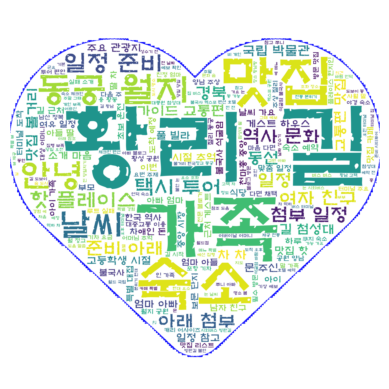

In [135]:
import numpy as np
from PIL import Image
mask = np.array(Image.open('data/heart.jpg'))
wordcloud1 = WordCloud(
    font_path="C:/Windows/Fonts/H2MKPB.TTF",
    background_color='white',
    colormap = color_map,
    max_words = 200,
    mask = mask,
    contour_color='blue',
    contour_width=1,
    stopwords=불용어
)
wordcloud1.generate(kj)
plt.imshow(wordcloud1, interpolation='bilinear')
plt.axis('off')
plt.show()

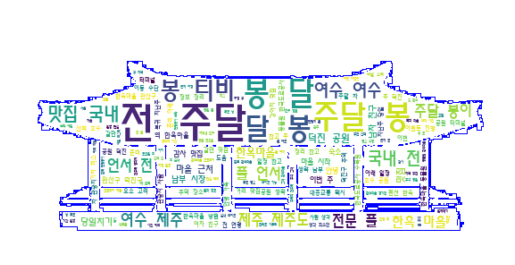

In [137]:
mask = np.array(Image.open('data/korea-house-black-fill.png'))
wordcloud2 = WordCloud(
    font_path="C:/Windows/Fonts/HMFMMUEX.TTC",
    background_color='white',
    colormap = color_map,
    stopwords=불용어,
    max_words=200,
    mask = mask,
    contour_color='blue',
    contour_width=1
)
wordcloud2.generate(jj)
plt.imshow(wordcloud2, interpolation='bilinear')
plt.axis('off')
plt.show()

In [138]:
wordcloud1.to_file('data/naver_kin_경주.jpg')
wordcloud2.to_file('data/naver_kin_전주.jpg')

# 단어 빈도수 시각화(nltk.Text)

In [175]:
print(df_kj_noun[:5])
print(df_jj_noun[:5])

['추석', '추석', '생각', '서울', '버스']
['곳', '추천', '추억', '다양', '체험']


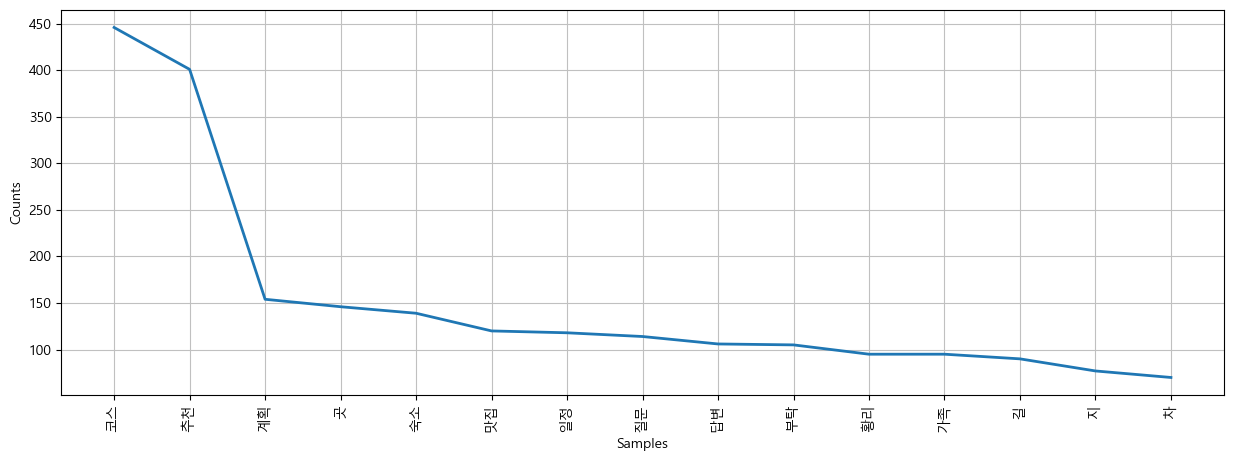

In [178]:
import nltk
import matplotlib.pyplot as plt
word, count = zip(*data_text.vocab().most_common(15))
data_text = nltk.Text(df_kj_noun)
plt.figure(figsize=(15,5))
plt.rc('font', family='Malgun Gothic')
data_text.plot(15)
plt.show()

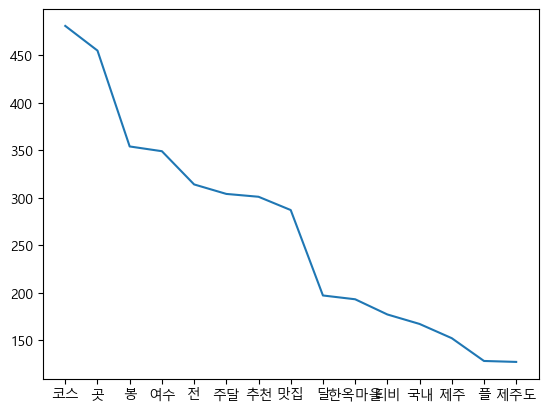

<Figure size 1500x500 with 0 Axes>

In [181]:
word, count = zip(*data_text.vocab().most_common(15))
plt.plot(word, count)
plt.figure(figsize=(15,5))
plt.rc('font', family='Malgun Gothic')
plt.show()

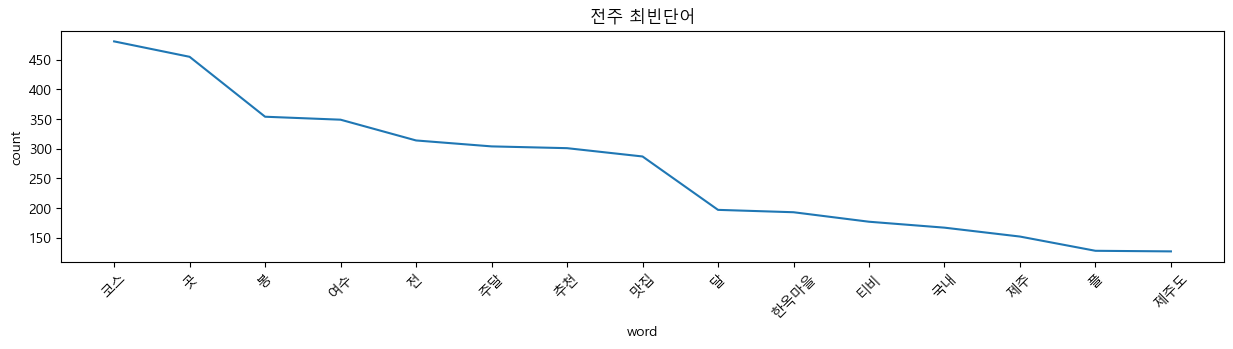

In [182]:
word, counts = zip(*data_text.vocab().most_common(15))
plt.figure(figsize=(15,3))
plt.plot(word, counts)
plt.xticks(rotation=45)
plt.xlabel('word')
plt.ylabel('count')
plt.title('전주 최빈단어')
plt.show()

# 6. Word2Vec

In [147]:
df = pd.read_csv('data/naver_kin.csv', sep='\t')
total_text_list = df['total_text'].to_list()
total_text_list[0]

' 전주  가볼만한곳 추천 받아요  추억의 7080 다양한체험 7080감성 추억여행 테마박물관 유익한시간 2 전북 전북투어패스 통합이용권 전북핫플 여러여행지 다양한체험 카페이용추가 전주여행 필수 편안하고 즐거운 날이 되시길 바라겠습니다 감사합니다 '

In [158]:
select_pos = ['NNP', 'NNG']
불용어 = {'여학생'}

In [159]:
from mecab import MeCab
mecab = MeCab()
total_noun_list = []
for total_text in total_text_list:
    noun_list = [token for token, tag in mecab.pos(total_text)
                if tag in select_pos and
                len(token)>=2 and
                token not in 불용어]
    total_noun_list.append(noun_list)

In [160]:
from gensim.models import Word2Vec
model = Word2Vec(
    total_noun_list, window=10, workers=-1, sg=1
)

In [165]:
model.wv.most_similar('전주')

[('주말', 0.3698463439941406),
 ('포토', 0.2762660086154938),
 ('시내버스', 0.2533281147480011),
 ('워터', 0.24960343539714813),
 ('가실', 0.24882428348064423),
 ('전라', 0.2285403162240982),
 ('공용', 0.2213573008775711),
 ('엄마', 0.21197080612182617),
 ('날짜', 0.21178807318210602),
 ('평상시', 0.20583979785442352)]

In [162]:
model.wv.most_similar('경주')

[('위치', 0.3641005754470825),
 ('추가', 0.21867415308952332),
 ('걱정', 0.21632219851016998),
 ('고려', 0.2159893959760666),
 ('월드', 0.21469099819660187),
 ('사이트', 0.2134207934141159),
 ('다윈', 0.20914912223815918),
 ('체증', 0.20906010270118713),
 ('정복', 0.2070489227771759),
 ('불편', 0.20607852935791016)]